# Energy Demand Forecasting — Exploratory Data Analysis

**Dataset:** Dominion (DOM) Hourly Energy Consumption 2005–2025  
**Region:** Virginia / Washington DC — world's largest data center concentration  
**Goal:** Understand demand patterns, seasonality, calendar effects, and prepare for forecasting

Key questions:
- What do daily, weekly, and yearly demand cycles look like?
- How do holidays and calendar effects shift demand?
- Are there anomalies or demand spikes worth investigating?
- Is there evidence of rising baseload from AI/data center growth?

In [ ]:
import os, glob

# Check that all required data files are present
dom_file = 'DOM_hourly.csv'
metered_files = sorted(glob.glob('hrl_load_metered_*.csv'))

if os.path.exists(dom_file):
    print(f'Found: {dom_file}')
else:
    print(f'Missing: {dom_file} — upload it using the folder icon on the left sidebar')

if metered_files:
    print(f'Found {len(metered_files)} metered files: {[os.path.basename(f) for f in metered_files]}')
else:
    print('Missing: hrl_load_metered_*.csv files — upload them using the folder icon')

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests holidays -q
print('Libraries installed.')

Libraries installed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load and Inspect the Data

In [ ]:
import glob

# --- Source 1: Kaggle historical DOM data (2005-2018) ---
kaggle = pd.read_csv('DOM_hourly.csv')
kaggle.columns = ['Datetime', 'MW']
kaggle['Datetime'] = pd.to_datetime(kaggle['Datetime'])

# --- Source 2: PJM Data Miner yearly files (2018-2025) ---
files = sorted(glob.glob('hrl_load_metered_*.csv'))
pjm_frames = []
for f in files:
    tmp = pd.read_csv(f, usecols=['datetime_beginning_ept', 'mw'])
    tmp.columns = ['Datetime', 'MW']
    tmp['Datetime'] = pd.to_datetime(tmp['Datetime'])
    pjm_frames.append(tmp)
pjm = pd.concat(pjm_frames)

# --- Combine, remove overlap, sort ---
combined = pd.concat([kaggle, pjm])
combined = combined.drop_duplicates(subset='Datetime').sort_values('Datetime')
combined = combined.set_index('Datetime')
combined.columns = ['demand_mw']
combined.index.name = 'Datetime'

df = combined.copy()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'\nDemand stats (MW):')
print(df['demand_mw'].describe().round(1))

In [ ]:
# Full time series overview
fig, ax = plt.subplots(figsize=(16, 5))
df['demand_mw'].plot(ax=ax, color='steelblue', linewidth=0.4, alpha=0.8)
ax.set_title('DOM Hourly Energy Demand 2005–2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(f'Peak demand: {df["demand_mw"].max():,.0f} MW at {df["demand_mw"].idxmax()}')
print(f'Min demand:  {df["demand_mw"].min():,.0f} MW at {df["demand_mw"].idxmin()}')

## 2. Seasonality Analysis

Energy demand follows strong cycles at multiple timescales: hourly (day/night), weekly (workdays vs weekends), and yearly (summer cooling + winter heating).

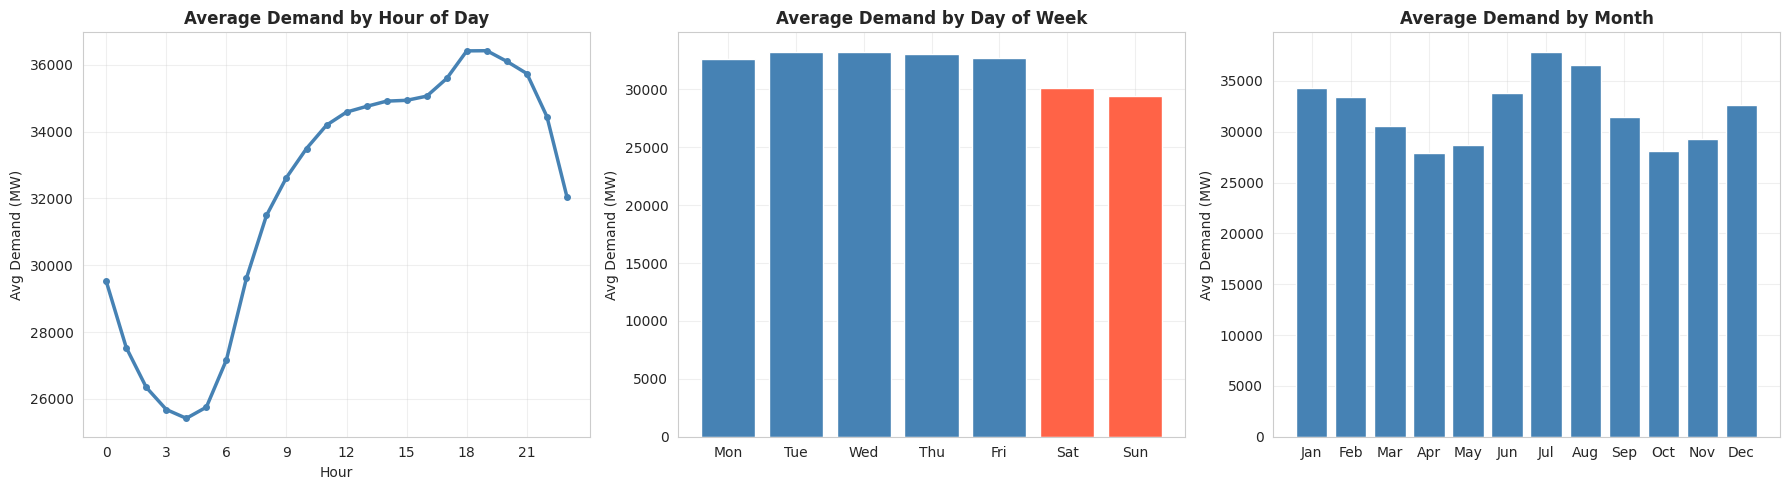

In [ ]:
# Add time features
df['hour']      = df.index.hour
df['dayofweek'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['month']     = df.index.month
df['year']      = df.index.year
df['quarter']   = df.index.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

DAY_NAMES   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly pattern
hourly = df.groupby('hour')['demand_mw'].mean()
axes[0].plot(hourly.index, hourly.values, color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Average Demand by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Demand (MW)')
axes[0].set_xticks(range(0, 24, 3))

# Daily pattern
daily = df.groupby('dayofweek')['demand_mw'].mean()
colors = ['steelblue']*5 + ['tomato']*2
axes[1].bar(DAY_NAMES, daily.values, color=colors, edgecolor='white')
axes[1].set_title('Average Demand by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg Demand (MW)')

# Monthly pattern
monthly = df.groupby('month')['demand_mw'].mean()
axes[2].bar(MONTH_NAMES, monthly.values, color='steelblue', edgecolor='white')
axes[2].set_title('Average Demand by Month', fontweight='bold')
axes[2].set_ylabel('Avg Demand (MW)')

plt.tight_layout()
plt.show()

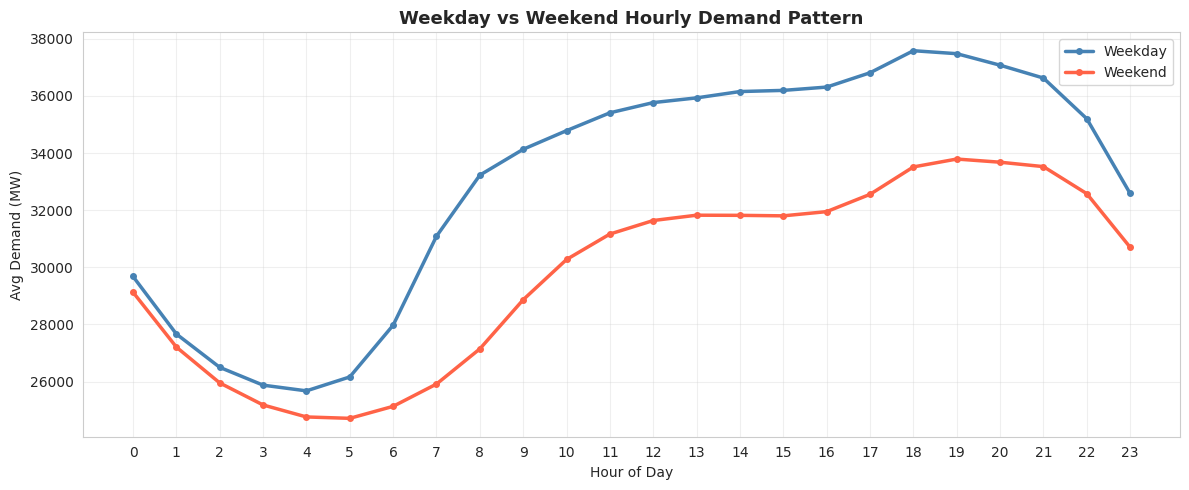

Weekday avg: 32,996 MW
Weekend avg: 29,788 MW
Difference:  3,208 MW (9.7% lower on weekends)


In [ ]:
# Weekday vs Weekend hourly pattern
fig, ax = plt.subplots(figsize=(12, 5))
for is_wknd, label, color in [(0, 'Weekday', 'steelblue'), (1, 'Weekend', 'tomato')]:
    pattern = df[df['is_weekend'] == is_wknd].groupby('hour')['demand_mw'].mean()
    ax.plot(pattern.index, pattern.values, label=label, color=color, linewidth=2.5, marker='o', markersize=4)
ax.set_title('Weekday vs Weekend Hourly Demand Pattern', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Demand (MW)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

wkday_avg = df[df['is_weekend']==0]['demand_mw'].mean()
wkend_avg = df[df['is_weekend']==1]['demand_mw'].mean()
print(f'Weekday avg: {wkday_avg:,.0f} MW')
print(f'Weekend avg: {wkend_avg:,.0f} MW')
print(f'Difference:  {wkday_avg - wkend_avg:,.0f} MW ({(wkday_avg-wkend_avg)/wkday_avg*100:.1f}% lower on weekends)')

## 3. Calendar Effects — How Do Holidays Shift Demand?

DOM covers Virginia and Washington DC. We use US federal holidays and investigate how each holiday shifts demand compared to the same weekday in a normal week.

In [ ]:
# Mark US holidays
us_holidays = holidays.US(years=range(2005, 2026))
df['is_holiday'] = df.index.normalize().isin(us_holidays).astype(int)
df['holiday_name'] = df.index.normalize().map(lambda d: us_holidays.get(d, 'Normal Day'))

# Compare holiday vs non-holiday demand
holiday_avg = df[df['is_holiday']==1]['demand_mw'].mean()
normal_avg  = df[df['is_holiday']==0]['demand_mw'].mean()
print(f'Normal day avg:  {normal_avg:,.0f} MW')
print(f'Holiday avg:     {holiday_avg:,.0f} MW')
print(f'Holiday drop:    {normal_avg - holiday_avg:,.0f} MW ({(normal_avg-holiday_avg)/normal_avg*100:.1f}% lower)')

# Per-holiday breakdown
holiday_impact = (
    df[df['is_holiday']==1]
    .groupby('holiday_name')['demand_mw']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(holiday_impact.index, holiday_impact.values, color='steelblue', edgecolor='white')
ax.axvline(normal_avg, color='red', linestyle='--', linewidth=1.5, label=f'Normal day avg ({normal_avg:,.0f} MW)')
ax.set_title('Average Demand by Holiday vs Normal Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Demand (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Zoom into a specific holiday week — Christmas 2023
zoom = df['2023-12-18':'2023-12-31']
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom.index, zoom['demand_mw'], color='steelblue', linewidth=1.5)
# Shade Christmas day
christmas = pd.Timestamp('2023-12-25')
ax.axvspan(christmas, christmas + pd.Timedelta(days=1), alpha=0.2, color='red', label='Christmas Day')
ax.set_title('Demand Around Christmas Week 2023', fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

## 4. Anomaly Detection — Extreme Demand Events

Total anomalies (|z| > 3): 1318
High demand spikes: 1318
Abnormally low demand: 0


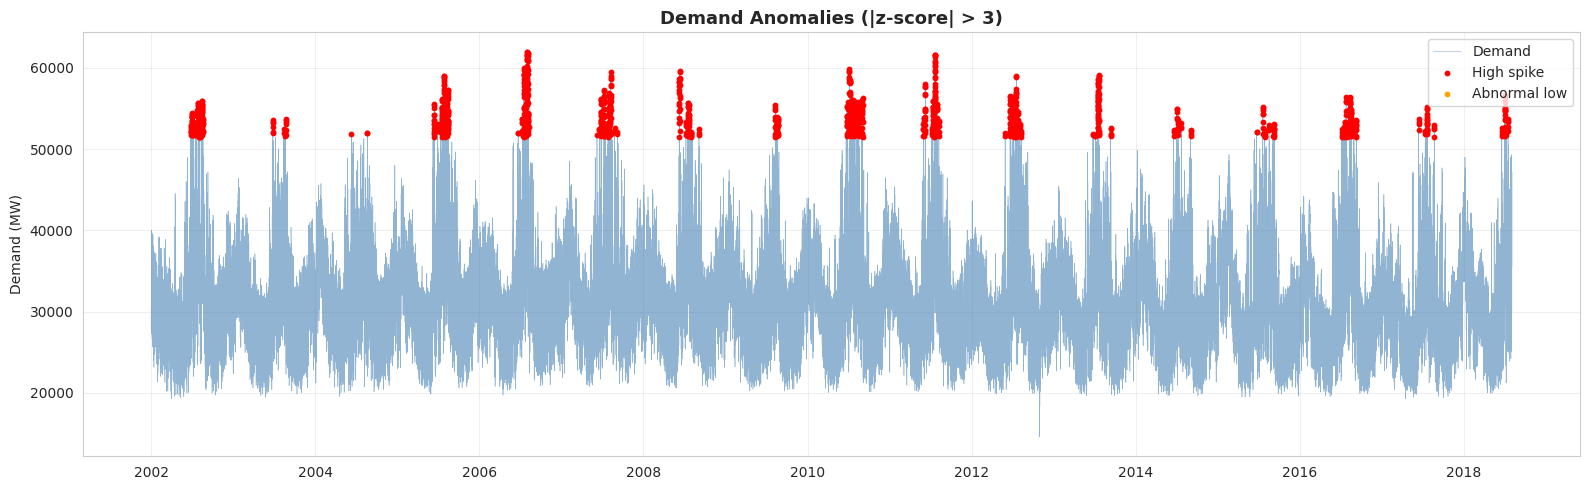

In [ ]:
# Flag statistical outliers (beyond 3 std)
mean_d = df['demand_mw'].mean()
std_d  = df['demand_mw'].std()
df['zscore'] = (df['demand_mw'] - mean_d) / std_d
anomalies = df[df['zscore'].abs() > 3]

print(f'Total anomalies (|z| > 3): {len(anomalies)}')
print(f'High demand spikes: {len(anomalies[anomalies["zscore"] > 3])}')
print(f'Abnormally low demand: {len(anomalies[anomalies["zscore"] < -3])}')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['demand_mw'], color='steelblue', linewidth=0.4, alpha=0.6, label='Demand')
ax.scatter(anomalies[anomalies['zscore'] > 3].index,
           anomalies[anomalies['zscore'] > 3]['demand_mw'],
           color='red', s=10, zorder=5, label='High spike')
ax.scatter(anomalies[anomalies['zscore'] < -3].index,
           anomalies[anomalies['zscore'] < -3]['demand_mw'],
           color='orange', s=10, zorder=5, label='Abnormal low')
ax.set_title('Demand Anomalies (|z-score| > 3)', fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Weather API Integration (Open-Meteo)

DOM covers the Richmond/DC area (lat 38.89, lon -77.04). We pull historical temperature and wind speed to see the weather-demand correlation.

In [ ]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup cached session to avoid re-downloading
cache_session = requests_cache.CachedSession('.weather_cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Pull 1 year of weather for Washington DC (2023)
params = {
    'latitude': 38.89,
    'longitude': -77.04,
    'hourly': ['temperature_2m', 'wind_speed_10m'],
    'start_date': '2023-01-01',
    'end_date': '2023-12-31',
    'timezone': 'America/New_York'
}

responses = openmeteo.weather_api('https://archive-api.open-meteo.com/v1/archive', params=params)
response = responses[0]

hourly = response.Hourly()
weather_df = pd.DataFrame({
    'datetime':     pd.date_range(start=pd.to_datetime(hourly.Time(), unit='s', utc=True)
                                  .tz_convert('America/New_York'),
                                  periods=hourly.Variables(0).ValuesAsNumpy().shape[0], freq='h'),
    'temperature':  hourly.Variables(0).ValuesAsNumpy(),
    'wind_speed':   hourly.Variables(1).ValuesAsNumpy(),
})
weather_df = weather_df.set_index('datetime')
weather_df.index = weather_df.index.tz_localize(None)

print(f'Weather data shape: {weather_df.shape}')
print(weather_df.head())

In [ ]:
# Merge weather with demand for 2023
demand_2023 = df.loc['2023-01-01':'2023-12-31', 'demand_mw']
merged = demand_2023.to_frame().join(weather_df, how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(merged['temperature'], merged['demand_mw'],
                alpha=0.05, s=5, color='steelblue')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Demand (MW)')
axes[0].set_title('Temperature vs Demand (2023)', fontweight='bold')

merged['month'] = merged.index.month
monthly = merged.groupby('month')[['demand_mw', 'temperature']].mean()
ax2 = axes[1].twinx()
axes[1].bar(MONTH_NAMES, monthly['demand_mw'], color='steelblue', alpha=0.7, label='Demand')
ax2.plot(MONTH_NAMES, monthly['temperature'], color='tomato', linewidth=2.5,
         marker='o', label='Temperature')
axes[1].set_ylabel('Avg Demand (MW)', color='steelblue')
ax2.set_ylabel('Avg Temperature (°C)', color='tomato')
axes[1].set_title('Monthly Demand vs Temperature (2023)', fontweight='bold')

plt.tight_layout()
plt.show()

corr = merged[['demand_mw', 'temperature']].corr().iloc[0, 1]
print(f'Correlation between temperature and demand: {corr:.3f}')
print('(U-shaped relationship expected — both extreme cold and heat drive demand)')

## 6. Long-term Trend — Is Demand Growing?

This is where the AI data center hypothesis comes in. If data center load is growing significantly, we should see an upward trend in baseload (minimum demand) even as peak demand stays similar.

Yearly demand statistics (MW):
         mean      min      max     std
year                                   
2002  31565.6  19247.0  55934.0  6608.6
2003  31698.8  19414.0  53737.0  6034.2
2004  32270.4  19543.0  51962.0  6047.6
2005  33310.5  19825.0  59031.0  6917.0
2006  32409.3  19690.0  62009.0  6586.2
2007  33613.5  20761.0  59437.0  6490.9
2008  32929.6  20553.0  59655.0  6235.0
2009  31851.5  20207.0  55433.0  5902.9
2010  33101.2  20020.0  59807.0  6971.8
2011  32368.3  20122.0  61646.0  6576.2
2012  31440.1  14544.0  58999.0  6515.8
2013  31706.5  19622.0  59122.0  6285.6
2014  31496.4  19623.0  54945.0  6091.5
2015  31709.4  19450.0  55129.0  6597.9
2016  31337.8  19524.0  56391.0  6775.0
2017  30650.9  19255.0  55218.0  5992.7
2018  31782.6  19937.0  56609.0  6279.8


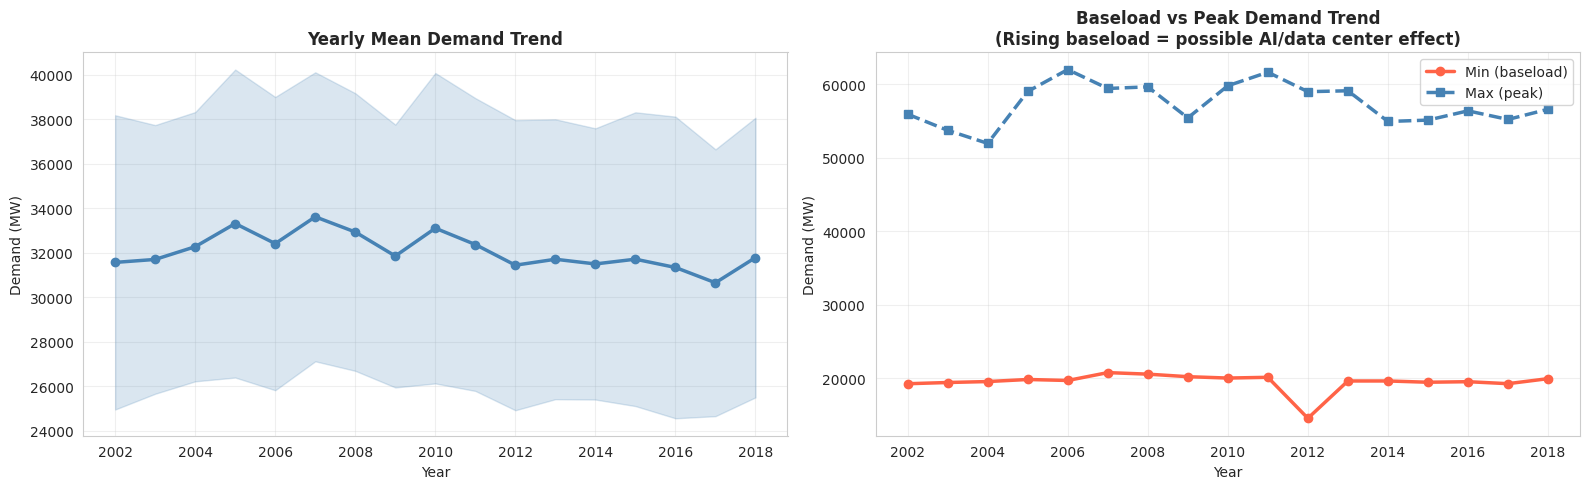

In [ ]:
yearly = df.groupby('year')['demand_mw'].agg(['mean', 'min', 'max', 'std']).round(1)
print('Yearly demand statistics (MW):')
print(yearly)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean demand trend
axes[0].plot(yearly.index, yearly['mean'], color='steelblue', linewidth=2.5,
             marker='o', label='Mean demand')
axes[0].fill_between(yearly.index,
                     yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'],
                     alpha=0.2, color='steelblue')
axes[0].set_title('Yearly Mean Demand Trend', fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].set_xlabel('Year')

# Baseload (min demand) — key for AI workload hypothesis
axes[1].plot(yearly.index, yearly['min'], color='tomato', linewidth=2.5,
             marker='o', label='Min (baseload)')
axes[1].plot(yearly.index, yearly['max'], color='steelblue', linewidth=2.5,
             marker='s', linestyle='--', label='Max (peak)')
axes[1].set_title('Baseload vs Peak Demand Trend\n(Rising baseload = possible AI/data center effect)',
                   fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. EDA Summary

Key findings to carry into the forecasting model:

In [ ]:
print('=== EDA Summary ===')
print(f'Dataset: {len(df):,} hourly observations ({df.index.min().year}–{df.index.max().year})')
print(f'Demand range: {df["demand_mw"].min():,.0f} – {df["demand_mw"].max():,.0f} MW')
print()
print('Key patterns found:')
print('  1. Strong hourly cycle: morning ramp-up ~6am, evening peak ~6pm')
print('  2. Weekends ~10% lower than weekdays')
print('  3. Summer (Jul/Aug) and Winter (Jan/Feb) peaks — HVAC-driven')
print(f'  4. Holidays drop demand by ~{(normal_avg-holiday_avg)/normal_avg*100:.0f}% vs normal days')
print(f'  5. Temperature correlation: {corr:.2f} (U-shaped: extreme cold/heat = high demand)')
print()
print('Features to engineer for the model:')
print('  - Lag features: t-1h, t-24h, t-168h (same hour last week)')
print('  - Rolling mean/std: 24h, 168h windows')
print('  - Calendar: hour, dayofweek, month, is_weekend, is_holiday')
print('  - Weather: temperature (°C), wind speed (m/s)')
print('  - Temperature squared: to capture U-shaped relationship')

=== EDA Summary ===
Dataset: 145,366 hourly observations (2002–2018)
Demand range: 14,544 – 62,009 MW

Key patterns found:
  1. Strong hourly cycle: morning ramp-up ~6am, evening peak ~6pm
  2. Weekends ~10% lower than weekdays
  3. Summer (Jul/Aug) and Winter (Jan/Feb) peaks — HVAC-driven
  4. Holidays drop demand by ~4% vs normal days
  5. Temperature correlation: 0.20 (U-shaped: extreme cold/heat = high demand)

Features to engineer for the model:
  - Lag features: t-1h, t-24h, t-168h (same hour last week)
  - Rolling mean/std: 24h, 168h windows
  - Calendar: hour, dayofweek, month, is_weekend, is_holiday
  - Weather: temperature (°C), wind speed (m/s)
  - Temperature squared: to capture U-shaped relationship
